# BindingDB Dataset Clustering (Kd)
## Fast clustering for LigandMPNN benchmarking

**Clustering criteria:**
1. Affinity tiers (tight binders vs non-binders)
2. Protein size bins
3. Ligand properties (from SMILES)

**Output:** clustered representatives

## 1. Setup

### 1-1. Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
import json
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print("✅ Imports complete")

✅ Imports complete


### 1-2. Configuration

In [2]:
# Input/Output paths
ASSAY_TYPE = "Kd"  # Options: Kd, IC50
INPUT_CSV = f"/scratch/yunmin/data/db/graph/bdb/filtered/bindingdb_{ASSAY_TYPE}_with_pdb_val_valid_pdb.csv"
OUT_DIR = Path("/scratch/yunmin/data/db/graph/bdb/clustered")
OUT_PLOTS_DIR = OUT_DIR / "plots"
OUT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Clustering parameters
TARGET_SAMPLES = 250
TIGHT_BINDER_CUTOFF = 8.5  # p{ASSAY_TYPE} >= 8.5 for tight binders
NON_BINDER_CUTOFF = 4.5     # p{ASSAY_TYPE} <= 4.5 for non-binders
MIN_TARGETS_PER_PROTEIN = 0
MIN_OFFTARGETS_PER_PROTEIN = 0

print(f"Configuration:")
print(f"  Input: {INPUT_CSV}")
print(f"  Output: {OUT_DIR}")
print(f"  Target samples: {TARGET_SAMPLES}")
print(f"  Tight binder cutoff: p{ASSAY_TYPE} >= {TIGHT_BINDER_CUTOFF}")
print(f"  Non-binder cutoff: p{ASSAY_TYPE} <= {NON_BINDER_CUTOFF}")

Configuration:
  Input: /scratch/yunmin/data/db/graph/bdb/filtered/bindingdb_Kd_with_pdb_val_valid_pdb.csv
  Output: /scratch/yunmin/data/db/graph/bdb/clustered
  Target samples: 250
  Tight binder cutoff: pKd >= 8.5
  Non-binder cutoff: pKd <= 4.5


## 2. Load Data

### 2-1. Load Data

In [3]:
print(f"Loading data from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
initial_rows = len(df)

print(f"\n✅ Loaded {initial_rows:,} rows")
print(f"  - Unique proteins: {df['protein_key'].nunique():,}")
print(f"  - Targets: {(df['target_type'] == 'target').sum():,}")
print(f"  - Off-targets: {(df['target_type'] == 'off_target').sum():,}")

# Show first few rows
df.head()

Loading data from /scratch/yunmin/data/db/graph/bdb/filtered/bindingdb_Kd_with_pdb_val_valid_pdb.csv...

✅ Loaded 625 rows
  - Unique proteins: 187
  - Targets: 395
  - Off-targets: 230


,protein_key,uniprot_id,target_name,target_source,sequence,sequence_length,ligand_inchikey,ligand_smiles,ligand_name,ligand_het_id,original_Kd_nM,representative_assay_nM,target_type,curation_source,doi,complex_pdb_id,valid_pdb_id,validation_status
0,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,FAKRSMQSSFJEIM-RQJHMYQMSA-N,C[C@H](CS)C(=O)N1CCC[C@H]1C(O)=O,(2S)-1-[(2S)-2-methyl-3-sulfanylpropanoyl]pyrr...,X8Z,435000,435000.000000,off_target,ChEMBL,10.1021/acs.jmedchem.3c00171,"4C1D,4C1F,4C1H,4DPR,3LUS,6V61,5ZIO,8SKO,4EXS,2...",5ZIO,Valid
1,O00255_UNK,O00255,Menin,NaN,MGLKAAQKTLFPLRSIDDVVRLFAAELGREEPDLVLLSLVLGFVEH...,615,DETOMBLLEOZTMZ-UHFFFAOYSA-N,Cc1c(CN2CCC(CC2)Nc2ncnc3sc(CC(F)(F)F)cc23)ccc2...,CHEMBL3780822,3XW,10.0; 9.3,9.643651,target,ChEMBL,10.1016/j.bmc.2017.11.045,4X5Y,4X5Y,Valid
2,O00255_UNK,O00255,Menin,NaN,MGLKAAQKTLFPLRSIDDVVRLFAAELGREEPDLVLLSLVLGFVEH...,615,PSOJDGBGVBEYJX-UHFFFAOYSA-N,FC(F)(F)Cc1cc2c(NC3CCN(Cc4ccc5[nH]c(cc5c4)C#N)...,CHEMBL3780497,3XY,24,24.000000,target,ChEMBL,10.1021/acs.jmedchem.5b01305,4X5Z,4X5Z,Valid
3,O00255_UNK,O00255,Menin,NaN,MGLKAAQKTLFPLRSIDDVVRLFAAELGREEPDLVLLSLVLGFVEH...,615,AUWUGRCKTQSGJY-UHFFFAOYSA-N,NC(C1CCCC1)(C1CCN(CCCOc2ccc(cc2)C#N)CC1)c1ccccc1,CHEMBL3126196,2SF,110000,110000.000000,off_target,ChEMBL,10.1021/acs.jmedchem.9b00021,4OG8,4OG8,Valid
4,O14936_Homo sapiens,O14936,Peripheral plasma membrane protein CASK,Homo sapiens,MADDDVLFEDVYELCEVIGKGPFSVVRRCINRETGQQFAVKIVDVA...,926,BPLPIBNWDLPUKP-UHFFFAOYSA-N,Cc1cc(Br)c(CNc2ncc(C(=O)NCCCN3CCOC3=O)c(NC3CCC...,CHEMBL4850857,V6B,22,22.000000,target,ChEMBL,10.1021/acs.jmedchem.1c00845,7OAK,7OAK,Valid


### 2-2. Initial Data Exploration

In [4]:
# Check available columns
print("Available columns:")
print(df.columns.tolist())

Available columns:
['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'original_Kd_nM', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status']


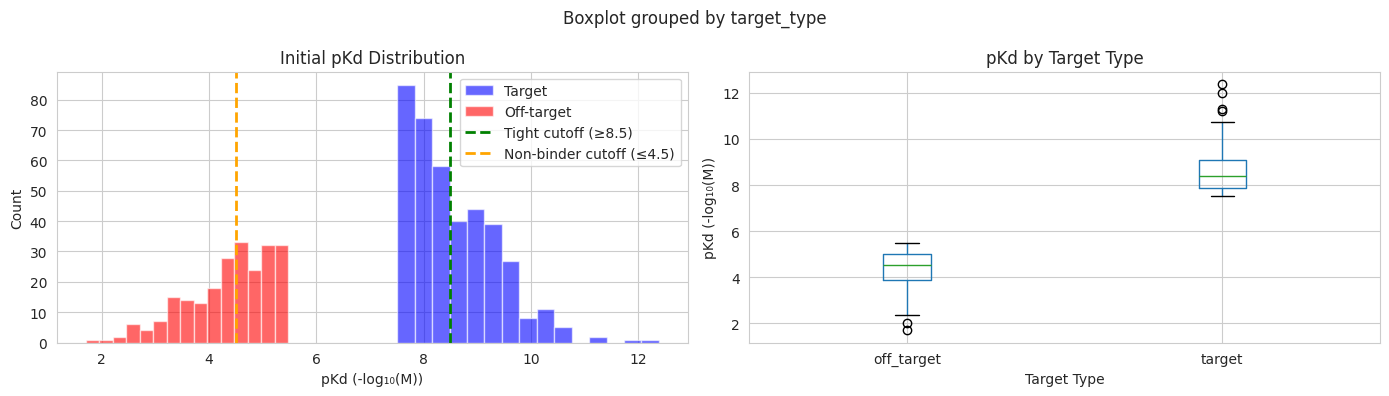

In [5]:
# Assay distribution (converted to pIC50)
# pKd/pIC50 = -log10(Kd/IC50 in M) = -log10(Kd_nM/IC50_nM × 10^-9) = 9 - log10(Kd_nM/IC50_nM)
df[f'p{ASSAY_TYPE}'] = 9 - np.log10(df['representative_assay_nM'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall distribution
axes[0].hist(df[df['target_type'] == 'target'][f'p{ASSAY_TYPE}'], bins=15, alpha=0.6, label='Target', color='blue')
axes[0].hist(df[df['target_type'] == 'off_target'][f'p{ASSAY_TYPE}'], bins=15, alpha=0.6, label='Off-target', color='red')
axes[0].axvline(TIGHT_BINDER_CUTOFF, color='green', linestyle='--', linewidth=2, label=f'Tight cutoff (≥{TIGHT_BINDER_CUTOFF})')
axes[0].axvline(NON_BINDER_CUTOFF, color='orange', linestyle='--', linewidth=2, label=f'Non-binder cutoff (≤{NON_BINDER_CUTOFF})')
axes[0].set_xlabel(f'p{ASSAY_TYPE} (-log₁₀(M))')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Initial p{ASSAY_TYPE} Distribution')
axes[0].legend()

# Box plot by target type
df.boxplot(column=f'p{ASSAY_TYPE}', by='target_type', ax=axes[1])
axes[1].set_title(f'p{ASSAY_TYPE} by Target Type')
axes[1].set_xlabel('Target Type')
axes[1].set_ylabel(f'p{ASSAY_TYPE} (-log₁₀(M))')

plt.tight_layout()
plt.show()

## 3. Protein Filtering (≥n targets AND ≥n off-targets)

### 3-1. Protein Filtering

In [6]:
print("="*60)
print("PROTEIN FILTERING: Ensuring sufficient targets/off-targets")
print("="*60)

MIN_TARGETS_PER_PROTEIN = 3
MIN_OFFTARGETS_PER_PROTEIN = 3

print(f"\nRequiring each protein to have:")
print(f"  - At least {MIN_TARGETS_PER_PROTEIN} target entries")
print(f"  - At least {MIN_OFFTARGETS_PER_PROTEIN} off-target entries")

# Count targets and off-targets per protein
protein_counts = df.groupby('protein_key')['target_type'].value_counts().unstack(fill_value=0)

# Ensure columns exist
if 'target' not in protein_counts.columns:
    protein_counts['target'] = 0
if 'off_target' not in protein_counts.columns:
    protein_counts['off_target'] = 0

print(f"\nBefore filtering:")
print(f"  - Total proteins: {len(protein_counts):,}")
print(f"  - Proteins with ≥{MIN_TARGETS_PER_PROTEIN} targets: {(protein_counts['target'] >= MIN_TARGETS_PER_PROTEIN).sum():,}")
print(f"  - Proteins with ≥{MIN_OFFTARGETS_PER_PROTEIN} off-targets: {(protein_counts['off_target'] >= MIN_OFFTARGETS_PER_PROTEIN).sum():,}")

# Filter proteins
valid_proteins = protein_counts[
    (protein_counts['target'] >= MIN_TARGETS_PER_PROTEIN) &
    (protein_counts['off_target'] >= MIN_OFFTARGETS_PER_PROTEIN)
].index

print(f"\n✅ After filtering:")
print(f"  - Valid proteins: {len(valid_proteins):,}")

# Filter dataframe
df_filtered = df[df['protein_key'].isin(valid_proteins)].copy()
print(f"  - Rows retained: {len(df_filtered):,} / {len(df):,} ({len(df_filtered)/len(df)*100:.1f}%)")

PROTEIN FILTERING: Ensuring sufficient targets/off-targets

Requiring each protein to have:
  - At least 3 target entries
  - At least 3 off-target entries

Before filtering:
  - Total proteins: 187
  - Proteins with ≥3 targets: 49
  - Proteins with ≥3 off-targets: 31

✅ After filtering:
  - Valid proteins: 16
  - Rows retained: 179 / 625 (28.6%)


### 3-2. Detailed per-protein target/off-target analysis


PER-PROTEIN TARGET/OFF-TARGET ANALYSIS


/tmp/ipykernel_990770/1723524644.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(box_data, labels=['Targets', 'Off-targets'],


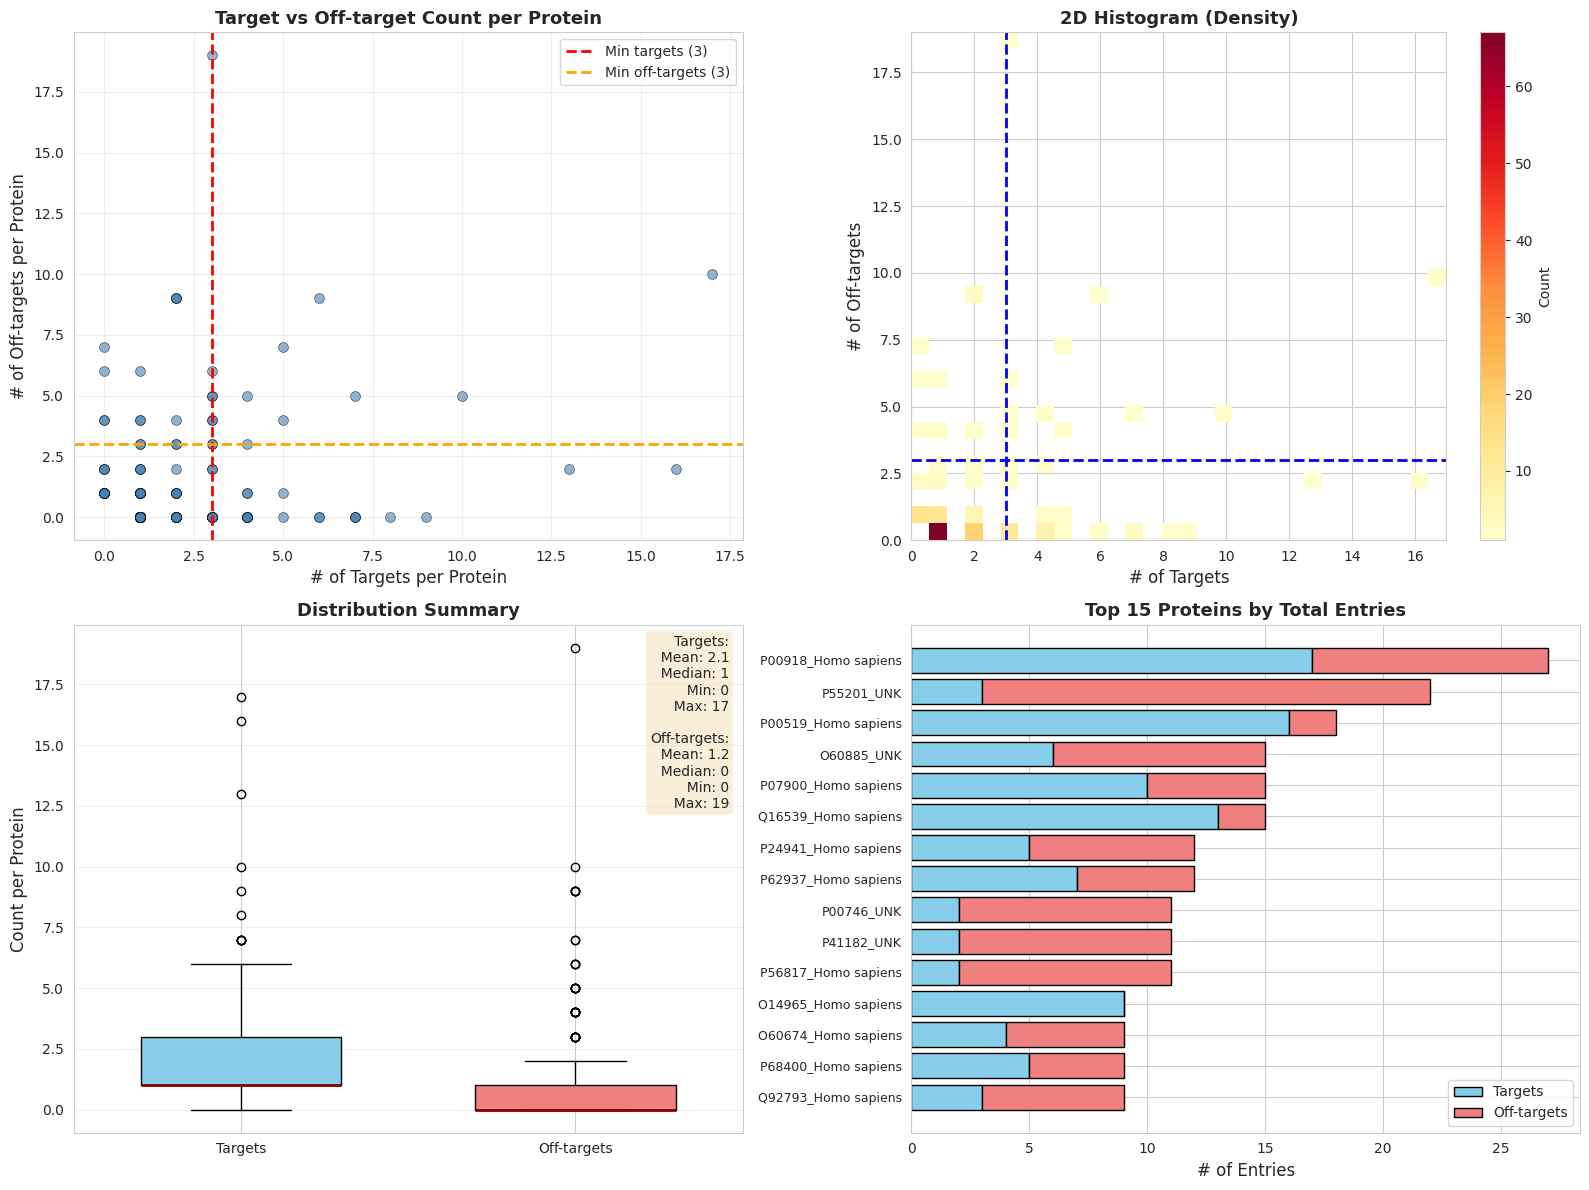

✅ Saved protein analysis plot to /scratch/yunmin/data/db/graph/bdb/clustered/plots/Kd_protein_target_offtarget_analysis.png

Detailed Statistics:
# of proteins: 187

Targets per protein:
  Mean ± Std: 2.1 ± 2.4
  Median (IQR): 1 (1-3)
  Range: 0-17

Off-targets per protein:
  Mean ± Std: 1.2 ± 2.4
  Median (IQR): 0 (0-1)
  Range: 0-19

Total entries per protein:
  Mean ± Std: 3.3 ± 3.8
  Range: 1-27

Proteins with most targets (top 5):
target_type          target  off_target  total
protein_key                                   
P00918_Homo sapiens      17          10     27
P00519_Homo sapiens      16           2     18
Q16539_Homo sapiens      13           2     15
P07900_Homo sapiens      10           5     15
O14965_Homo sapiens       9           0      9

Proteins with most off-targets (top 5):
target_type          target  off_target  total
protein_key                                   
P55201_UNK                3          19     22
P00918_Homo sapiens      17          10     27
O6

In [7]:
print("\n" + "="*60)
print("PER-PROTEIN TARGET/OFF-TARGET ANALYSIS")
print("="*60)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter plot: Targets vs Off-targets per protein
axes[0, 0].scatter(protein_counts[(protein_counts['target']<=100) & (protein_counts['off_target']<=100)]['target'], 
                   protein_counts[(protein_counts['target']<=100) & (protein_counts['off_target']<=100)]['off_target'], 
                   alpha=0.6, s=50, color='steelblue', edgecolors='black', linewidth=0.5)
axes[0, 0].axvline(MIN_TARGETS_PER_PROTEIN, color='red', linestyle='--', linewidth=2, label=f'Min targets ({MIN_TARGETS_PER_PROTEIN})')
axes[0, 0].axhline(MIN_OFFTARGETS_PER_PROTEIN, color='orange', linestyle='--', linewidth=2, label=f'Min off-targets ({MIN_OFFTARGETS_PER_PROTEIN})')
axes[0, 0].set_xlabel('# of Targets per Protein', fontsize=12)
axes[0, 0].set_ylabel('# of Off-targets per Protein', fontsize=12)
axes[0, 0].set_title('Target vs Off-target Count per Protein', fontweight='bold', fontsize=13)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Joint distribution histogram
axes[0, 1].hist2d(protein_counts['target'], protein_counts['off_target'], 
                  bins=30, cmap='YlOrRd', cmin=1)
axes[0, 1].axvline(MIN_TARGETS_PER_PROTEIN, color='blue', linestyle='--', linewidth=2)
axes[0, 1].axhline(MIN_OFFTARGETS_PER_PROTEIN, color='blue', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('# of Targets', fontsize=12)
axes[0, 1].set_ylabel('# of Off-targets', fontsize=12)
axes[0, 1].set_title('2D Histogram (Density)', fontweight='bold', fontsize=13)
plt.colorbar(axes[0, 1].collections[0], ax=axes[0, 1], label='Count')

# 3. Box plot comparison
box_data = [protein_counts['target'], protein_counts['off_target']]
bp = axes[1, 0].boxplot(box_data, labels=['Targets', 'Off-targets'], 
                        patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('skyblue')
bp['boxes'][1].set_facecolor('lightcoral')
for median in bp['medians']:
    median.set(color='darkred', linewidth=2)
axes[1, 0].set_ylabel('Count per Protein', fontsize=12)
axes[1, 0].set_title('Distribution Summary', fontweight='bold', fontsize=13)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add statistics text
stats_text = f"Targets:\n"
stats_text += f"  Mean: {protein_counts['target'].mean():.1f}\n"
stats_text += f"  Median: {protein_counts['target'].median():.0f}\n"
stats_text += f"  Min: {protein_counts['target'].min()}\n"
stats_text += f"  Max: {protein_counts['target'].max()}\n\n"
stats_text += f"Off-targets:\n"
stats_text += f"  Mean: {protein_counts['off_target'].mean():.1f}\n"
stats_text += f"  Median: {protein_counts['off_target'].median():.0f}\n"
stats_text += f"  Min: {protein_counts['off_target'].min()}\n"
stats_text += f"  Max: {protein_counts['off_target'].max()}"

axes[1, 0].text(0.98, 0.98, stats_text, transform=axes[1, 0].transAxes,
                fontsize=10, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Top proteins by total entries
protein_counts['total'] = protein_counts['target'] + protein_counts['off_target']
top_proteins = protein_counts.nlargest(15, 'total')

y_pos = np.arange(len(top_proteins))
axes[1, 1].barh(y_pos, top_proteins['target'], label='Targets', color='skyblue', edgecolor='black')
axes[1, 1].barh(y_pos, top_proteins['off_target'], left=top_proteins['target'], 
                label='Off-targets', color='lightcoral', edgecolor='black')
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels([name[:30] + '...' if len(name) > 30 else name for name in top_proteins.index], fontsize=9)
axes[1, 1].set_xlabel('# of Entries', fontsize=12)
axes[1, 1].set_title('Top 15 Proteins by Total Entries', fontweight='bold', fontsize=13)
axes[1, 1].legend()
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / f'{ASSAY_TYPE}_protein_target_offtarget_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved protein analysis plot to {OUT_DIR / 'plots' / f'{ASSAY_TYPE}_protein_target_offtarget_analysis.png'}")

# Print detailed statistics
print(f"\nDetailed Statistics:")
print(f"{'='*60}")
print(f"# of proteins: {len(protein_counts)}")
print(f"\nTargets per protein:")
print(f"  Mean ± Std: {protein_counts['target'].mean():.1f} ± {protein_counts['target'].std():.1f}")
print(f"  Median (IQR): {protein_counts['target'].median():.0f} ({protein_counts['target'].quantile(0.25):.0f}-{protein_counts['target'].quantile(0.75):.0f})")
print(f"  Range: {protein_counts['target'].min()}-{protein_counts['target'].max()}")

print(f"\nOff-targets per protein:")
print(f"  Mean ± Std: {protein_counts['off_target'].mean():.1f} ± {protein_counts['off_target'].std():.1f}")
print(f"  Median (IQR): {protein_counts['off_target'].median():.0f} ({protein_counts['off_target'].quantile(0.25):.0f}-{protein_counts['off_target'].quantile(0.75):.0f})")
print(f"  Range: {protein_counts['off_target'].min()}-{protein_counts['off_target'].max()}")

print(f"\nTotal entries per protein:")
print(f"  Mean ± Std: {protein_counts['total'].mean():.1f} ± {protein_counts['total'].std():.1f}")
print(f"  Range: {protein_counts['total'].min()}-{protein_counts['total'].max()}")

# Show proteins with extreme counts
print(f"\n{'='*60}")
print("Proteins with most targets (top 5):")
print(protein_counts.nlargest(5, 'target')[['target', 'off_target', 'total']])

print(f"\nProteins with most off-targets (top 5):")
print(protein_counts.nlargest(5, 'off_target')[['target', 'off_target', 'total']])

print(f"\nProteins with most total entries (top 5):")
print(protein_counts.nlargest(5, 'total')[['target', 'off_target', 'total']])

### 3-3. Show distribution after filtering

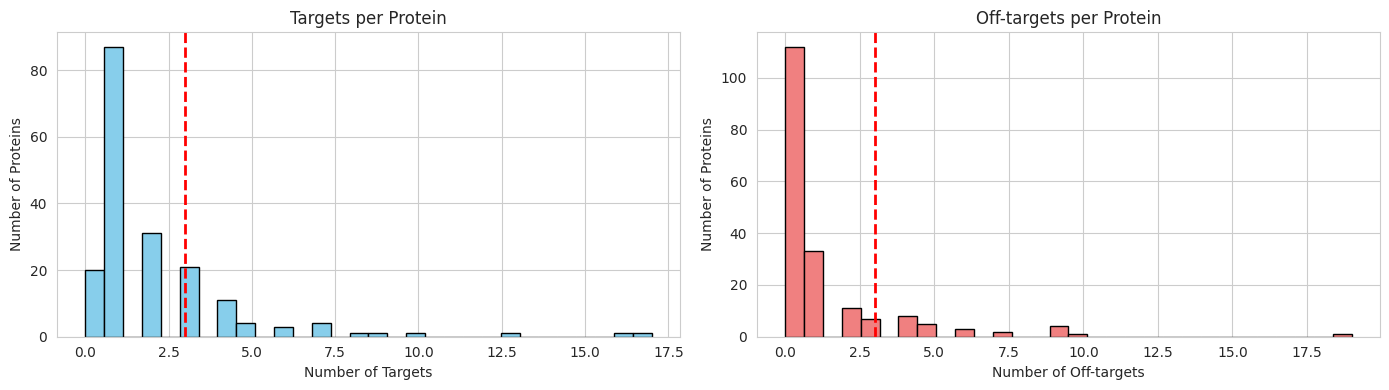


Statistics:
  Target entries - Mean: 2.1, Median: 1
  Off-target entries - Mean: 1.2, Median: 0


In [8]:
protein_counts = df.groupby('protein_key')['target_type'].value_counts().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Targets per protein
axes[0].hist(protein_counts['target'], bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(MIN_TARGETS_PER_PROTEIN, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Number of Targets')
axes[0].set_ylabel('Number of Proteins')
axes[0].set_title('Targets per Protein')

# Off-targets per protein
axes[1].hist(protein_counts['off_target'], bins=30, color='lightcoral', edgecolor='black')
axes[1].axvline(MIN_OFFTARGETS_PER_PROTEIN, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Number of Off-targets')
axes[1].set_ylabel('Number of Proteins')
axes[1].set_title('Off-targets per Protein')

plt.tight_layout()
plt.show()

print(f"\nStatistics:")
print(f"  Target entries - Mean: {protein_counts['target'].mean():.1f}, Median: {protein_counts['target'].median():.0f}")
print(f"  Off-target entries - Mean: {protein_counts['off_target'].mean():.1f}, Median: {protein_counts['off_target'].median():.0f}")

## 4. Feature Engineering

### 4-1. Affinity Tiers

Affinity tier distribution:
affinity_tier
weak_binder (>4.5)        51
non_binder (≤4.5)         46
moderate_binder (<8.5)    45
tight_binder (>=8.5)      37
Name: count, dtype: int64


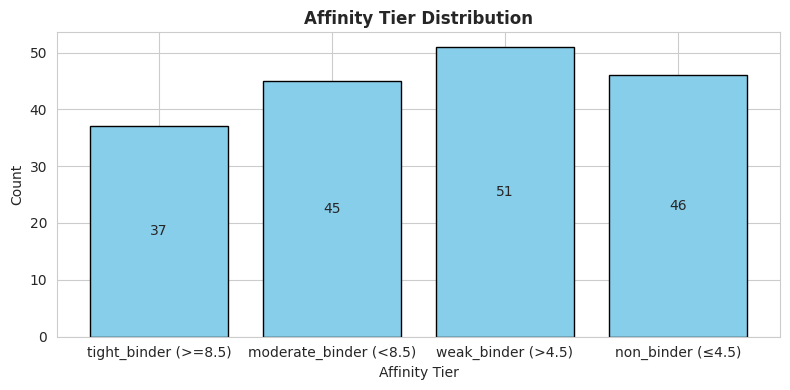

In [9]:
def classify_affinity_tier(row):
    """Classify into affinity tiers with focus on extreme binders."""
    p_assay = row[f'p{ASSAY_TYPE}']  # Use pKd/pIC50, not raw nM
    target_type = row['target_type']
    
    if target_type == 'target':
        if p_assay >= TIGHT_BINDER_CUTOFF:
            return f'tight_binder (>={TIGHT_BINDER_CUTOFF})'
        else:
            return f'moderate_binder (<{TIGHT_BINDER_CUTOFF})'
    else:  # off_target
        if p_assay <= NON_BINDER_CUTOFF:
            return f'non_binder (≤{NON_BINDER_CUTOFF})'
        else:
            return f'weak_binder (>{NON_BINDER_CUTOFF})'

df_filtered['affinity_tier'] = df_filtered.apply(classify_affinity_tier, axis=1)
print("Affinity tier distribution:")
print(df_filtered['affinity_tier'].value_counts())

# Visualize Bar graph
order=[
    f'tight_binder (>={TIGHT_BINDER_CUTOFF})',
    f'moderate_binder (<{TIGHT_BINDER_CUTOFF})',
    f'weak_binder (>{NON_BINDER_CUTOFF})',
    f'non_binder (≤{NON_BINDER_CUTOFF})',
    ]
df_filtered['affinity_tier'] = pd.Categorical(df_filtered['affinity_tier'], categories=order, ordered=True)
counts = df_filtered['affinity_tier'].value_counts(sort=False)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax.set_title('Affinity Tier Distribution', fontweight='bold')
ax.set_xlabel('Affinity Tier')
ax.set_ylabel('Count')
ax.bar_label(bars, labels=[f'{v}' for v in counts.values], label_type='center', padding=0)

plt.tight_layout()
plt.show()

### 4-2. Protein Size Categories

Size distribution:
size_category
very_large    91
medium        64
large         24
Name: count, dtype: int64


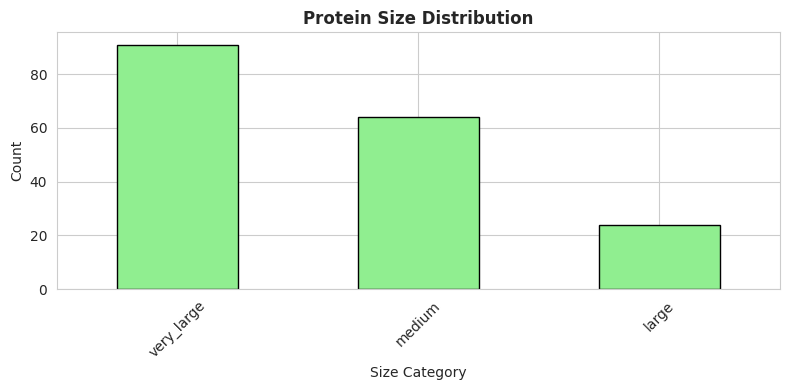

In [10]:
def categorize_protein_size(seq_length):
    """Categorize protein by sequence length."""
    if seq_length < 150:
        return 'small'
    elif seq_length < 300:
        return 'medium'
    elif seq_length < 500:
        return 'large'
    else:
        return 'very_large'

df_filtered['size_category'] = df_filtered['sequence_length'].apply(categorize_protein_size)

print("Size distribution:")
print(df_filtered['size_category'].value_counts())

# Visualize
df_filtered['size_category'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black', figsize=(8, 4))
plt.title('Protein Size Distribution', fontweight='bold')
plt.xlabel('Size Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4-3. Ligand Properties (from SMILES)

In [11]:
def calculate_ligand_features(smiles):
    """Calculate ligand properties from SMILES."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        
        return {
            'mw': Descriptors.MolWt(mol),
            'logp': Descriptors.MolLogP(mol),
            'hbd': Lipinski.NumHDonors(mol),
            'hba': Lipinski.NumHAcceptors(mol),
            'rotatable_bonds': Lipinski.NumRotatableBonds(mol),
            'aromatic_rings': Lipinski.NumAromaticRings(mol),
            'heavy_atoms': Lipinski.HeavyAtomCount(mol)
        }
    except:
        return None

def categorize_ligand_size(mw):
    """Categorize ligand by molecular weight."""
    if mw < 250:
        return 'small'
    elif mw < 400:
        return 'medium'
    elif mw < 600:
        return 'large'
    else:
        return 'very_large'

print("Calculating ligand properties...")
ligand_features = [calculate_ligand_features(smiles) for smiles in df_filtered['ligand_smiles']]
ligand_df = pd.DataFrame(ligand_features)

valid_ligands = ligand_df.notna().all(axis=1).sum()
print(f"  - Valid ligands: {valid_ligands:,} / {len(df_filtered):,}")

if valid_ligands < len(df_filtered):
    print(f"  - Failed: {len(df_filtered) - valid_ligands:,}")
    ligand_df = ligand_df.fillna(ligand_df.median())

df_filtered = pd.concat([df_filtered.reset_index(drop=True), ligand_df], axis=1)
df_filtered['ligand_size'] = df_filtered['mw'].apply(categorize_ligand_size)

print("\nLigand size distribution:")
print(df_filtered['ligand_size'].value_counts())

Calculating ligand properties...
  - Valid ligands: 179 / 179

Ligand size distribution:
ligand_size
medium        76
large         48
small         46
very_large     9
Name: count, dtype: int64


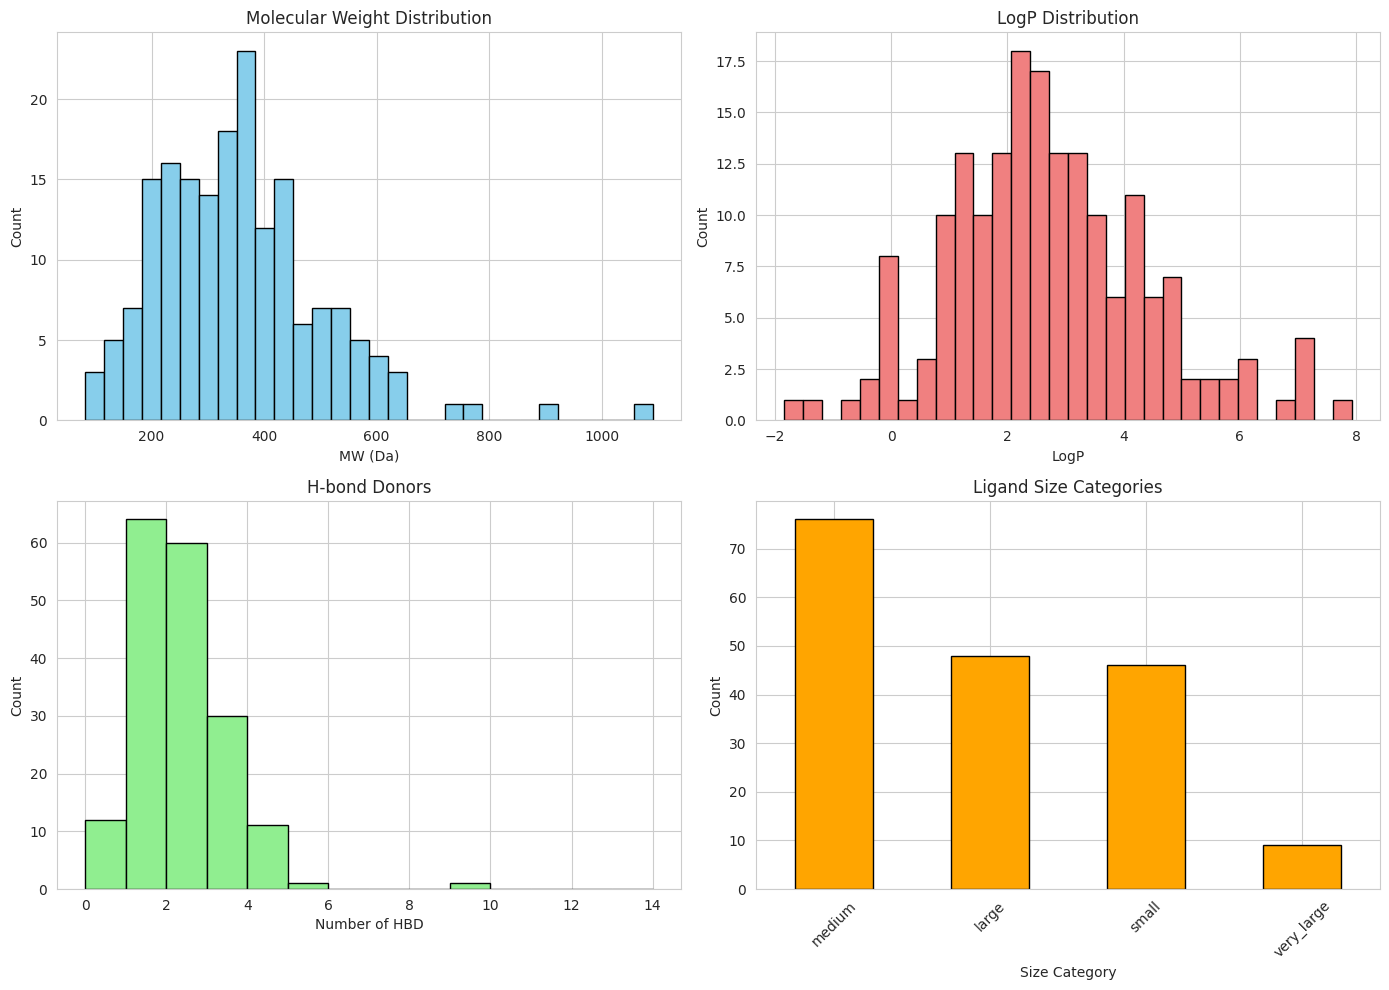

In [12]:
# Visualize ligand properties
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_filtered['mw'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Molecular Weight Distribution')
axes[0, 0].set_xlabel('MW (Da)')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(df_filtered['logp'], bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('LogP Distribution')
axes[0, 1].set_xlabel('LogP')
axes[0, 1].set_ylabel('Count')

axes[1, 0].hist(df_filtered['hbd'], bins=range(0, 15), color='lightgreen', edgecolor='black')
axes[1, 0].set_title('H-bond Donors')
axes[1, 0].set_xlabel('Number of HBD')
axes[1, 0].set_ylabel('Count')

df_filtered['ligand_size'].value_counts().plot(kind='bar', ax=axes[1, 1], color='orange', edgecolor='black')
axes[1, 1].set_title('Ligand Size Categories')
axes[1, 1].set_xlabel('Size Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Clustering & Sampling

### 7-1. Clustering Strategy

In [13]:
# Define cluster keys
cluster_keys = [
    'affinity_tier',
    'size_category',
    'ligand_size'
]

# Create composite cluster ID
df_filtered['cluster_id'] = df_filtered[cluster_keys].astype(str).agg('_'.join, axis=1)

n_clusters = df_filtered['cluster_id'].nunique()
print(f"Total clusters: {n_clusters:,}")
print(f"Target samples: {TARGET_SAMPLES}")
print(f"Samples per cluster: {max(1, TARGET_SAMPLES // n_clusters)}")

# Show cluster distribution
cluster_sizes = df_filtered['cluster_id'].value_counts()
print(f"\nCluster size statistics:")
print(f"  Mean: {cluster_sizes.mean():.1f}")
print(f"  Median: {cluster_sizes.median():.0f}")
print(f"  Min: {cluster_sizes.min()}")
print(f"  Max: {cluster_sizes.max()}")

Total clusters: 32
Target samples: 250
Samples per cluster: 7

Cluster size statistics:
  Mean: 5.6
  Median: 4
  Min: 1
  Max: 19


### 7-2. Stratified Sampling

In [14]:
print("="*60)
print("BALANCED SAMPLING WITH DIVERSITY")
print("="*60)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Sampling parameters
SAMPLES_PER_PROTEIN = 3  # Take 3 targets and 3 off-targets per protein

print(f"Strategy: Sample {SAMPLES_PER_PROTEIN} targets + {SAMPLES_PER_PROTEIN} off-targets per protein")
print(f"  - Ensure tight binders (p{ASSAY_TYPE} >= {TIGHT_BINDER_CUTOFF}) in targets")
print(f"  - Ensure non-binders (p{ASSAY_TYPE} <= {NON_BINDER_CUTOFF}) in off-targets")
print(f"  - Apply diversity sampling within each category\n")

def diversity_sample(group, n_sample):
    """Sample diverse representatives using K-means clustering."""
    if len(group) <= n_sample:
        return group
    
    candidates = group.copy()
    features = candidates[['mw', 'logp', 'hbd', 'hba', 'rotatable_bonds', 
                           'aromatic_rings', f'p{ASSAY_TYPE}']].fillna(0)
    
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    n_clusters = min(n_sample, len(candidates))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    candidates['cluster'] = kmeans.fit_predict(features_scaled)
    
    selected = []
    for cluster_id in range(n_clusters):
        cluster_samples = candidates[candidates['cluster'] == cluster_id]
        sample = cluster_samples.sample(n=1, random_state=42)
        selected.append(sample)
    
    return pd.concat(selected).drop('cluster', axis=1)

# Sample from each protein
all_samples = []
proteins_sampled = 0

for protein_name, protein_group in df_filtered.groupby('protein_key'):
    # Separate targets and off-targets
    targets = protein_group[protein_group['target_type'] == 'target']
    off_targets = protein_group[protein_group['target_type'] == 'off_target']
    
    # Prioritize tight binders in targets
    tight_targets = targets[targets[f'p{ASSAY_TYPE}'] >= TIGHT_BINDER_CUTOFF]
    other_targets = targets[targets[f'p{ASSAY_TYPE}'] < TIGHT_BINDER_CUTOFF]
    
    # Prioritize non-binders in off-targets
    non_binders = off_targets[off_targets[f'p{ASSAY_TYPE}'] <= NON_BINDER_CUTOFF]
    weak_binders = off_targets[off_targets[f'p{ASSAY_TYPE}'] > NON_BINDER_CUTOFF]
    
    # Sample targets (prefer tight binders)
    if len(tight_targets) >= SAMPLES_PER_PROTEIN:
        target_selected = diversity_sample(tight_targets, SAMPLES_PER_PROTEIN)
    else:
        target_selected = tight_targets.copy()
        remaining = SAMPLES_PER_PROTEIN - len(tight_targets)
        if remaining > 0 and len(other_targets) > 0:
            target_selected = pd.concat([target_selected, 
                                        diversity_sample(other_targets, remaining)])
    
    # Sample off-targets (prefer non-binders)
    if len(non_binders) >= SAMPLES_PER_PROTEIN:
        offtarget_selected = diversity_sample(non_binders, SAMPLES_PER_PROTEIN)
    else:
        offtarget_selected = non_binders.copy()
        remaining = SAMPLES_PER_PROTEIN - len(non_binders)
        if remaining > 0 and len(weak_binders) > 0:
            offtarget_selected = pd.concat([offtarget_selected,
                                           diversity_sample(weak_binders, remaining)])
    
    # Only include if we have both targets and off-targets
    if len(target_selected) > 0 and len(offtarget_selected) > 0:
        all_samples.append(pd.concat([target_selected, offtarget_selected]))
        proteins_sampled += 1

final_selection = pd.concat(all_samples).reset_index(drop=True)

print(f"\n{'='*60}")
print(f"✅ FINAL SELECTION")
print(f"{'='*60}")
print(f"Proteins sampled: {proteins_sampled}")
print(f"Total samples: {len(final_selection):,}")
print(f"  - Targets: {(final_selection['target_type'] == 'target').sum()}")
print(f"  - Off-targets: {(final_selection['target_type'] == 'off_target').sum()}")

# Affinity breakdown
print(f"\nAffinity breakdown:")
tight = (final_selection['target_type'] == 'target') & (final_selection[f'p{ASSAY_TYPE}'] >= TIGHT_BINDER_CUTOFF)
moderate = (final_selection['target_type'] == 'target') & (final_selection[f'p{ASSAY_TYPE}'] < TIGHT_BINDER_CUTOFF)
non_bind = (final_selection['target_type'] == 'off_target') & (final_selection[f'p{ASSAY_TYPE}'] <= NON_BINDER_CUTOFF)
weak = (final_selection['target_type'] == 'off_target') & (final_selection[f'p{ASSAY_TYPE}'] > NON_BINDER_CUTOFF)

print(f"  Tight binders (p{ASSAY_TYPE} ≥ {TIGHT_BINDER_CUTOFF}): {tight.sum()}")
print(f"  Moderate binders (p{ASSAY_TYPE} < {TIGHT_BINDER_CUTOFF}): {moderate.sum()}")
print(f"  Non-binders (p{ASSAY_TYPE} ≤ {NON_BINDER_CUTOFF}): {non_bind.sum()}")
print(f"  Weak binders (p{ASSAY_TYPE} > {NON_BINDER_CUTOFF}): {weak.sum()}")

# Diversity check
print(f"\nChemical diversity:")
print(f"  MW: {float(final_selection['mw'].min()):.0f} - {float(final_selection['mw'].max()):.0f} Da (std: {float(final_selection['mw'].std()):.1f})")
print(f"  LogP: {float(final_selection['logp'].min()):.1f} - {float(final_selection['logp'].max()):.1f} (std: {float(final_selection['logp'].std()):.1f})")
print(f"  p{ASSAY_TYPE}: {float(final_selection[f'p{ASSAY_TYPE}'].min()):.1f} - {float(final_selection[f'p{ASSAY_TYPE}'].max()):.1f} (std: {float(final_selection[f'p{ASSAY_TYPE}'].std()):.1f})")
print(f"  HBD: {int(final_selection['hbd'].min())} - {int(final_selection['hbd'].max())}")
print(f"  HBA: {int(final_selection['hba'].min())} - {int(final_selection['hba'].max())}")

print(f"\nProtein diversity:")
print(f"  Size range: {final_selection['sequence_length'].min()} - {final_selection['sequence_length'].max()} residues")

BALANCED SAMPLING WITH DIVERSITY
Strategy: Sample 3 targets + 3 off-targets per protein
  - Ensure tight binders (pKd >= 8.5) in targets
  - Ensure non-binders (pKd <= 4.5) in off-targets
  - Apply diversity sampling within each category


✅ FINAL SELECTION
Proteins sampled: 16
Total samples: 96
  - Targets: 48
  - Off-targets: 48

Affinity breakdown:
  Tight binders (pKd ≥ 8.5): 28
  Moderate binders (pKd < 8.5): 20
  Non-binders (pKd ≤ 4.5): 32
  Weak binders (pKd > 4.5): 16

Chemical diversity:
  MW: 82 - 1090 Da (std: 169.7)
  LogP: -1.4 - 7.9 (std: 1.9)
  pKd: 1.7 - 11.3 (std: 2.4)
  HBD: 0 - 9
  HBA: 1 - 14

Protein diversity:
  Size range: 156 - 2442 residues


## 8. Final Selection Analysis

### 8-1. Final Selection Summary

In [15]:
print("Final selection breakdown:")
print(f"\nAffinity tiers:")
print(final_selection['affinity_tier'].value_counts())

print(f"\nSize categories:")
print(final_selection['size_category'].value_counts())

print(f"\nLigand sizes:")
print(final_selection['ligand_size'].value_counts())

Final selection breakdown:

Affinity tiers:
affinity_tier
non_binder (≤4.5)         32
tight_binder (>=8.5)      28
moderate_binder (<8.5)    20
weak_binder (>4.5)        16
Name: count, dtype: int64

Size categories:
size_category
very_large    47
medium        30
large         19
Name: count, dtype: int64

Ligand sizes:
ligand_size
medium        35
large         31
small         23
very_large     7
Name: count, dtype: int64


### 8-2. Feature Distributions

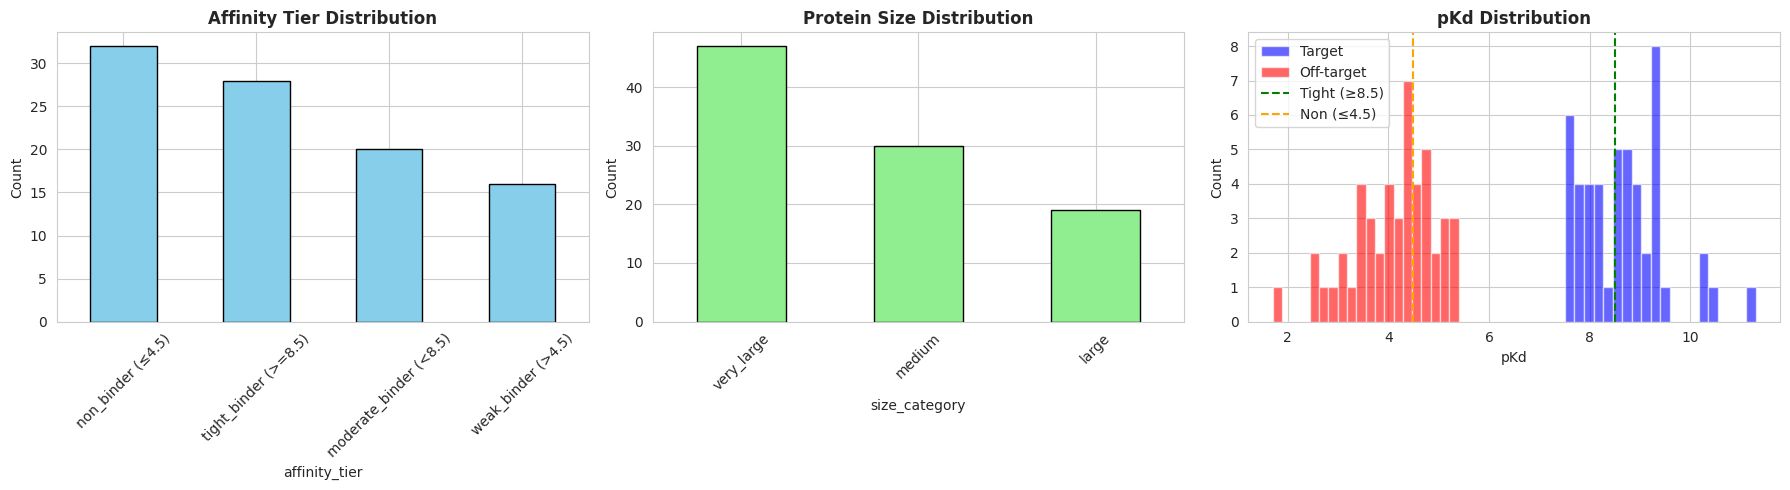

✅ Saved plot to /scratch/yunmin/data/db/graph/bdb/clustered/plots/bindingdb_Kd_clustering_stage1_distributions.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Affinity distribution
final_selection['affinity_tier'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Affinity Tier Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Size distribution
final_selection['size_category'].value_counts().plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Protein Size Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# p{ASSAY_TYPE} histogram
axes[2].hist(final_selection[final_selection['target_type'] == 'target'][f'p{ASSAY_TYPE}'], 
                bins=20, alpha=0.6, label='Target', color='blue')
axes[2].hist(final_selection[final_selection['target_type'] == 'off_target'][f'p{ASSAY_TYPE}'], 
                bins=20, alpha=0.6, label='Off-target', color='red')
axes[2].axvline(TIGHT_BINDER_CUTOFF, color='green', linestyle='--', label=f'Tight (≥{TIGHT_BINDER_CUTOFF})')
axes[2].axvline(NON_BINDER_CUTOFF, color='orange', linestyle='--', label=f'Non (≤{NON_BINDER_CUTOFF})')
axes[2].set_title(f'p{ASSAY_TYPE} Distribution', fontweight='bold')
axes[2].set_xlabel(f'p{ASSAY_TYPE}')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / f'bindingdb_{ASSAY_TYPE}_clustering_stage1_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved plot to {OUT_DIR / 'plots' / f'bindingdb_{ASSAY_TYPE}_clustering_stage1_distributions.png'}")

### 8-3. Before/After t-SNE Comparison

GENERATING BEFORE/AFTER t-SNE COMPARISON
Running t-SNE on filtered dataset (before sampling)...
Locating final selection in t-SNE space...
  Found 96 / 96 samples in visualization


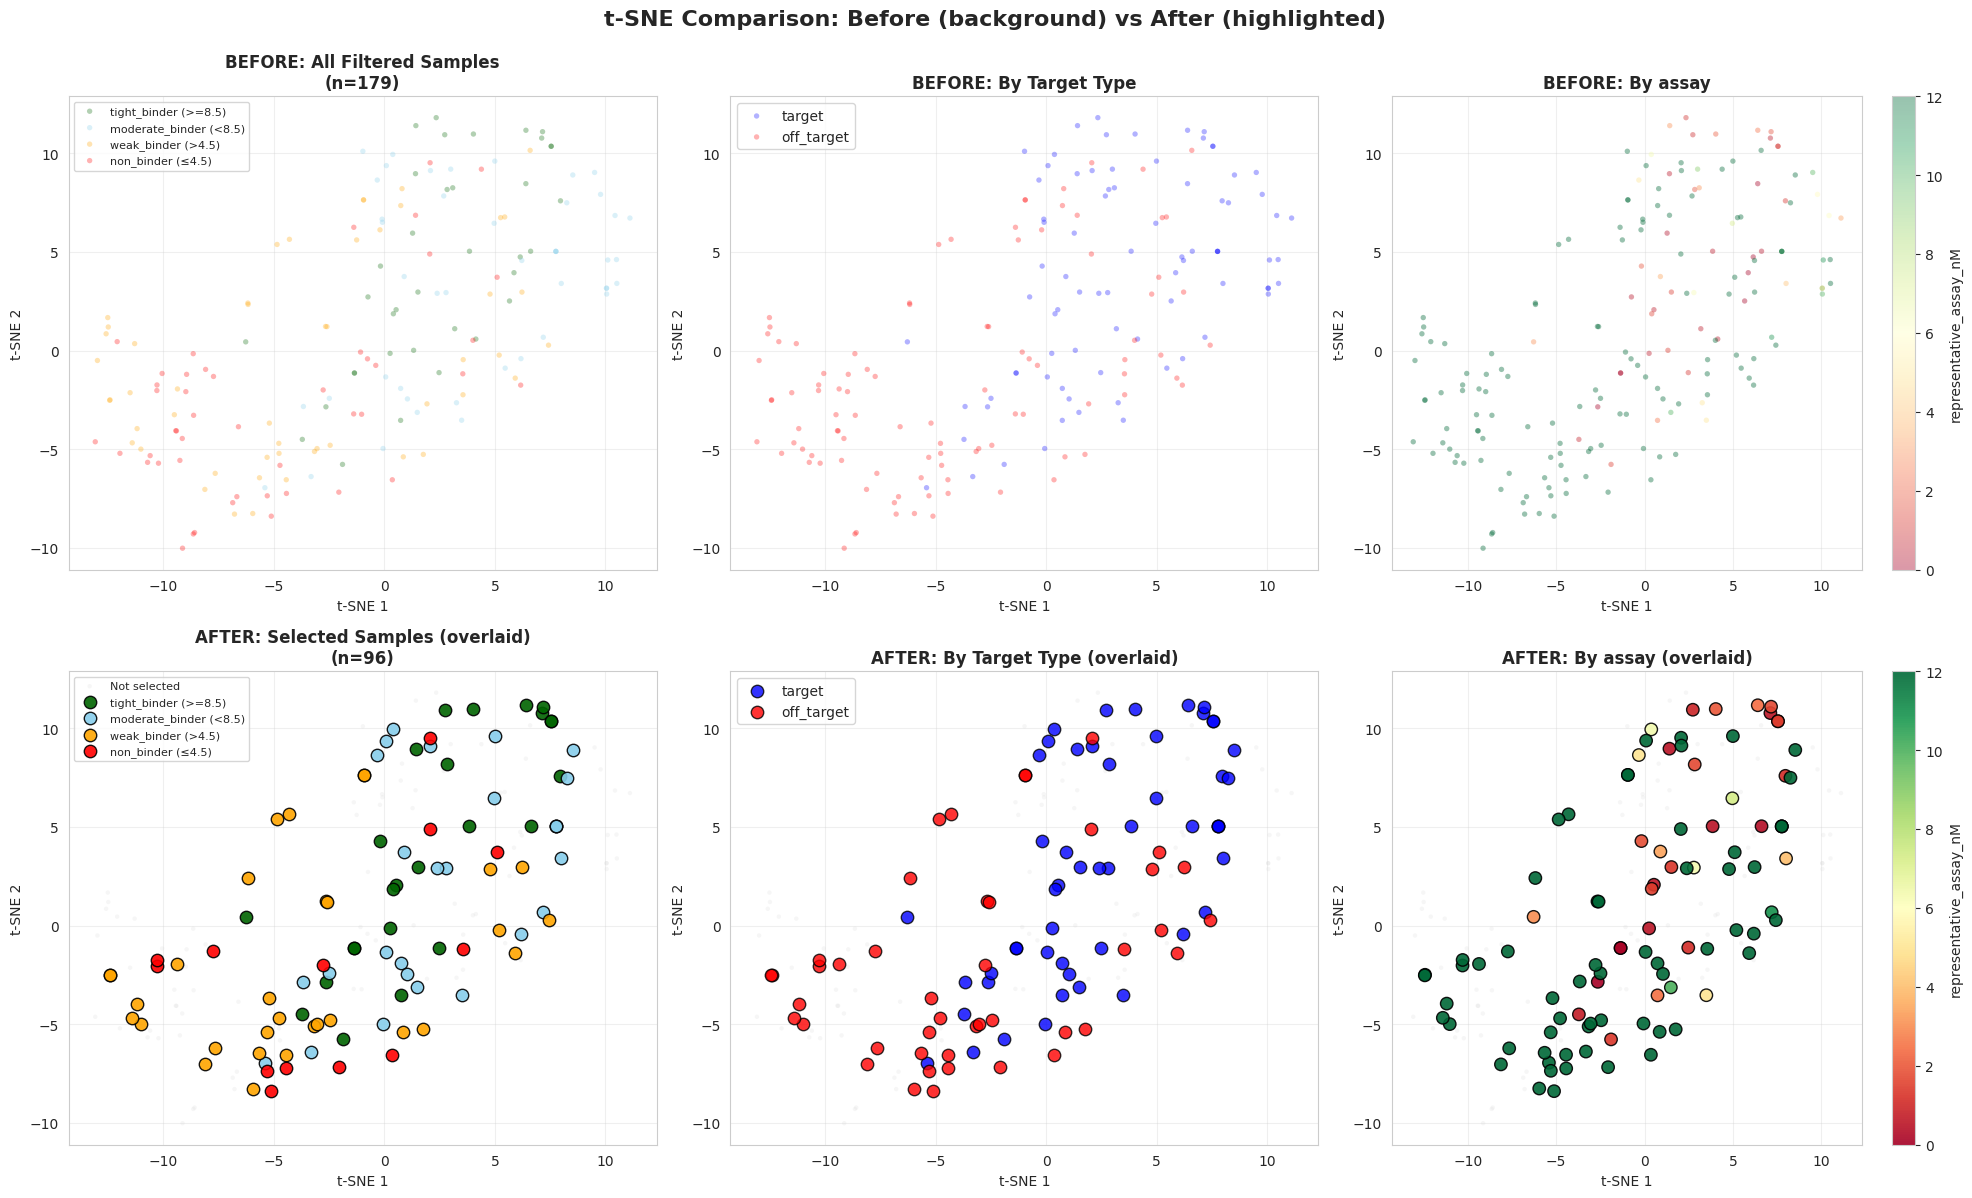

✅ Saved before/after t-SNE plot to /scratch/yunmin/data/db/graph/bdb/clustered/plots/bindingdb_Kd_clustering_tsne_before_after.png

SAMPLING IMPACT ANALYSIS

Dataset size:
  Before: 179 samples
  After:  96 samples
  Reduction: 46.4%

Affinity tier balance:
  Tier                                     Before     After      Change
  ----------------------------------------------------------------------
  weak_binder (>4.5)                         28.5%      16.7%    -11.8%
  non_binder (≤4.5)                          25.7%      33.3%    +7.6%
  moderate_binder (<8.5)                     25.1%      20.8%    -4.3%
  tight_binder (>=8.5)                       20.7%      29.2%    +8.5%

Target/Off-target balance:
  Targets:     Before 45.8% → After 50.0%
  Off-targets: Before 54.2% → After 50.0%


In [17]:
print("="*60)
print("GENERATING BEFORE/AFTER t-SNE COMPARISON")
print("="*60)

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Prepare features for the FILTERED dataset (before sampling)
print("Running t-SNE on filtered dataset (before sampling)...")
tsne_features_before = df_filtered[['mw', 'logp', 'hbd', 'hba', 'rotatable_bonds', 
                                     'aromatic_rings', 'heavy_atoms', 'representative_assay_nM', 
                                     'sequence_length',]].copy()
tsne_features_before = tsne_features_before.fillna(tsne_features_before.median())

# Standardize
scaler = StandardScaler()
tsne_features_before_scaled = scaler.fit_transform(tsne_features_before)

# Run t-SNE (sample if too large)
if len(df_filtered) > 5000:
    print(f"  Sampling {5000} points from {len(df_filtered)} for visualization...")
    sample_idx = df_filtered.sample(n=5000, random_state=42).index
    df_before_viz = df_filtered.loc[sample_idx]
    tsne_before_scaled = tsne_features_before_scaled[df_filtered.index.isin(sample_idx)]
else:
    df_before_viz = df_filtered
    tsne_before_scaled = tsne_features_before_scaled

tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(df_before_viz)-1))
tsne_coords_before = tsne.fit_transform(tsne_before_scaled)

# Find AFTER samples in the BEFORE coordinates
print("Locating final selection in t-SNE space...")
after_indices_in_before = df_before_viz.index.isin(final_selection.index)
tsne_coords_after_overlay = tsne_coords_before[after_indices_in_before]
final_selection_overlay = df_before_viz[after_indices_in_before]

print(f"  Found {len(final_selection_overlay)} / {len(final_selection)} samples in visualization")

# Create comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('t-SNE Comparison: Before (background) vs After (highlighted)', 
             fontsize=16, fontweight='bold', y=0.995)

# Column 1: By Affinity Tier
# Top: All samples (background)
for tier, color in zip([f'tight_binder (>={TIGHT_BINDER_CUTOFF})', 
                        f'moderate_binder (<{TIGHT_BINDER_CUTOFF})',
                        f'weak_binder (>{NON_BINDER_CUTOFF})',
                        f'non_binder (≤{NON_BINDER_CUTOFF})'],
                       ['darkgreen', 'skyblue', 'orange', 'red']):
    mask = df_before_viz['affinity_tier'] == tier
    if mask.sum() > 0:
        axes[0, 0].scatter(tsne_coords_before[mask, 0], tsne_coords_before[mask, 1], 
                          c=color, label=tier, alpha=0.3, s=15, edgecolors='none')
axes[0, 0].set_title(f'BEFORE: All Filtered Samples\n(n={len(df_before_viz):,})', 
                     fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('t-SNE 1')
axes[0, 0].set_ylabel('t-SNE 2')
axes[0, 0].legend(fontsize=8, loc='best')
axes[0, 0].grid(True, alpha=0.3)

# Bottom: Selected samples OVERLAID on same coordinates
axes[1, 0].scatter(tsne_coords_before[:, 0], tsne_coords_before[:, 1], 
                   c='lightgray', alpha=0.2, s=10, edgecolors='none', label='Not selected')
for tier, color in zip([f'tight_binder (>={TIGHT_BINDER_CUTOFF})', 
                        f'moderate_binder (<{TIGHT_BINDER_CUTOFF})',
                        f'weak_binder (>{NON_BINDER_CUTOFF})',
                        f'non_binder (≤{NON_BINDER_CUTOFF})'],
                       ['darkgreen', 'skyblue', 'orange', 'red']):
    mask = final_selection_overlay['affinity_tier'] == tier
    if mask.sum() > 0:
        axes[1, 0].scatter(tsne_coords_after_overlay[mask, 0], tsne_coords_after_overlay[mask, 1], 
                          c=color, label=tier, alpha=0.9, s=80, edgecolors='black', linewidth=1)
axes[1, 0].set_title(f'AFTER: Selected Samples (overlaid)\n(n={len(final_selection_overlay):,})', 
                     fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')
axes[1, 0].legend(fontsize=8, loc='best')
axes[1, 0].grid(True, alpha=0.3)

# Column 2: By Target Type
# Top: All samples
for ttype, color in zip(['target', 'off_target'], ['blue', 'red']):
    mask = df_before_viz['target_type'] == ttype
    axes[0, 1].scatter(tsne_coords_before[mask, 0], tsne_coords_before[mask, 1], 
                      c=color, label=ttype, alpha=0.3, s=15, edgecolors='none')
axes[0, 1].set_title(f'BEFORE: By Target Type', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('t-SNE 1')
axes[0, 1].set_ylabel('t-SNE 2')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Bottom: Selected samples overlaid
axes[1, 1].scatter(tsne_coords_before[:, 0], tsne_coords_before[:, 1], 
                   c='lightgray', alpha=0.2, s=10, edgecolors='none')
for ttype, color in zip(['target', 'off_target'], ['blue', 'red']):
    mask = final_selection_overlay['target_type'] == ttype
    axes[1, 1].scatter(tsne_coords_after_overlay[mask, 0], tsne_coords_after_overlay[mask, 1], 
                      c=color, label=ttype, alpha=0.8, s=80, edgecolors='black', linewidth=1)
axes[1, 1].set_title(f'AFTER: By Target Type (overlaid)', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('t-SNE 1')
axes[1, 1].set_ylabel('t-SNE 2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Column 3: By assay
# Top: All samples
scatter_before = axes[0, 2].scatter(tsne_coords_before[:, 0], tsne_coords_before[:, 1], 
                                    c=df_before_viz['representative_assay_nM'], cmap='RdYlGn', 
                                    alpha=0.4, s=15, edgecolors='none', vmin=0, vmax=12)
axes[0, 2].set_title(f'BEFORE: By assay', fontweight='bold', fontsize=12)
axes[0, 2].set_xlabel('t-SNE 1')
axes[0, 2].set_ylabel('t-SNE 2')
axes[0, 2].grid(True, alpha=0.3)
plt.colorbar(scatter_before, ax=axes[0, 2], label='representative_assay_nM')

# Bottom: Selected samples overlaid
axes[1, 2].scatter(tsne_coords_before[:, 0], tsne_coords_before[:, 1], 
                   c='lightgray', alpha=0.2, s=10, edgecolors='none')
scatter_after = axes[1, 2].scatter(tsne_coords_after_overlay[:, 0], tsne_coords_after_overlay[:, 1], 
                                   c=final_selection_overlay['representative_assay_nM'], cmap='RdYlGn', 
                                   alpha=0.9, s=80, edgecolors='black', linewidth=1, vmin=0, vmax=12)
axes[1, 2].set_title(f'AFTER: By assay (overlaid)', fontweight='bold', fontsize=12)
axes[1, 2].set_xlabel('t-SNE 1')
axes[1, 2].set_ylabel('t-SNE 2')
axes[1, 2].grid(True, alpha=0.3)
plt.colorbar(scatter_after, ax=axes[1, 2], label='representative_assay_nM')

plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / f'bindingdb_{ASSAY_TYPE}_clustering_tsne_before_after.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved before/after t-SNE plot to {OUT_DIR / 'plots' / f'bindingdb_{ASSAY_TYPE}_clustering_tsne_before_after.png'}")

# Print comparison statistics
print(f"\n{'='*60}")
print("SAMPLING IMPACT ANALYSIS")
print(f"{'='*60}")
print(f"\nDataset size:")
print(f"  Before: {len(df_filtered):,} samples")
print(f"  After:  {len(final_selection):,} samples")
print(f"  Reduction: {(1 - len(final_selection)/len(df_filtered))*100:.1f}%")

print(f"\nAffinity tier balance:")
before_affinity = df_filtered['affinity_tier'].value_counts(normalize=True) * 100
after_affinity = final_selection['affinity_tier'].value_counts(normalize=True) * 100
print(f"  {'Tier':<40} {'Before':<10} {'After':<10} {'Change'}")
print(f"  {'-'*70}")
for tier in before_affinity.index:
    before_pct = before_affinity.get(tier, 0)
    after_pct = after_affinity.get(tier, 0)
    change = after_pct - before_pct
    print(f"  {tier:<40} {before_pct:>6.1f}%    {after_pct:>6.1f}%    {change:+.1f}%")

print(f"\nTarget/Off-target balance:")
before_target = (df_filtered['target_type'] == 'target').sum() / len(df_filtered) * 100
after_target = (final_selection['target_type'] == 'target').sum() / len(final_selection) * 100
print(f"  Targets:     Before {before_target:.1f}% → After {after_target:.1f}%")
print(f"  Off-targets: Before {100-before_target:.1f}% → After {100-after_target:.1f}%")

### 8-4. Multi-dimensional Scatter Plots

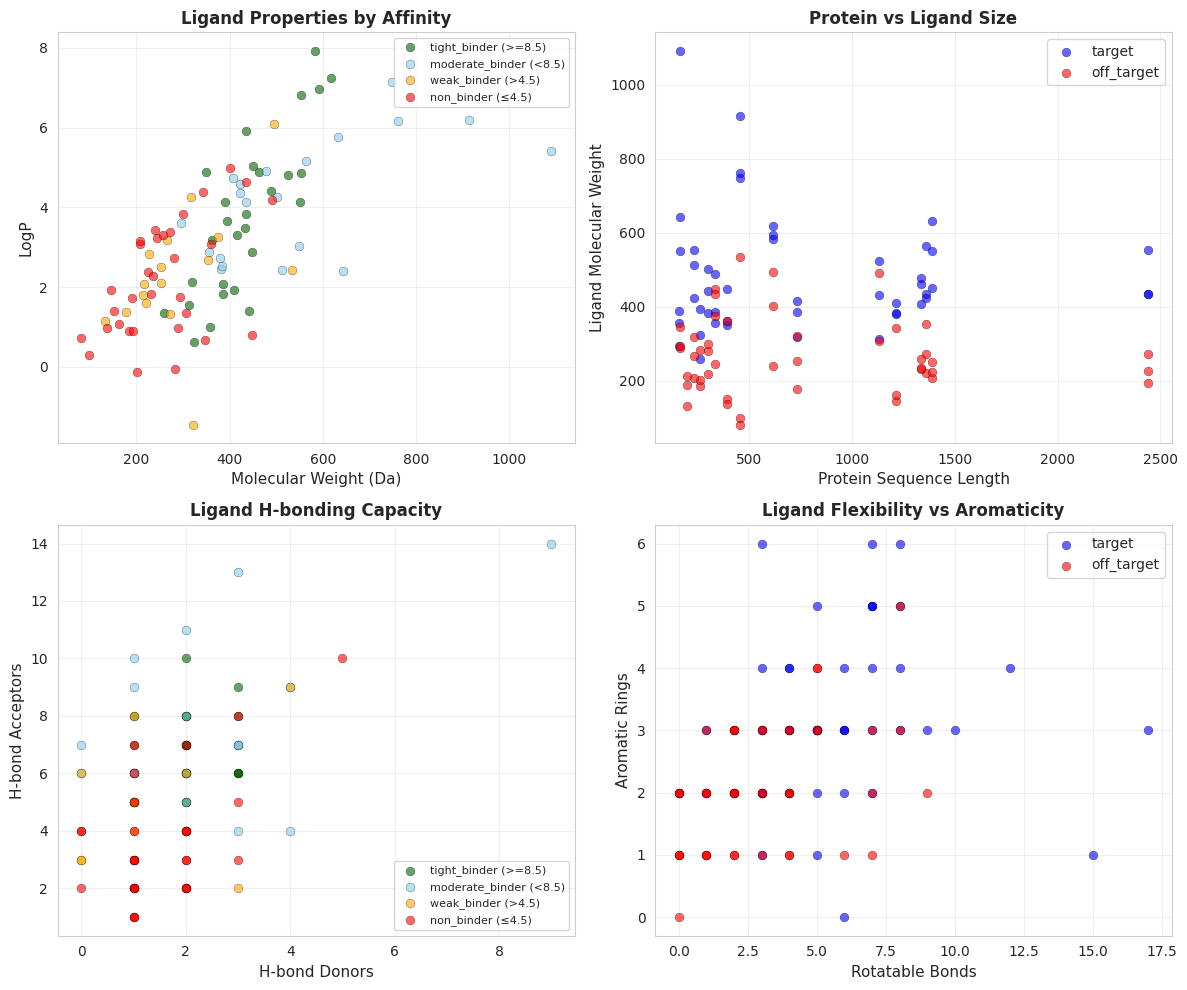

✅ Saved scatter analysis to /scratch/yunmin/data/db/graph/bdb/clustered/plots/bindingdb_Kd_clustering_scatter_analysis.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Molecular Weight vs LogP (colored by affinity)
for tier, color in zip([f'tight_binder (>={TIGHT_BINDER_CUTOFF})', 
                        f'moderate_binder (<{TIGHT_BINDER_CUTOFF})',
                        f'weak_binder (>{NON_BINDER_CUTOFF})',
                        f'non_binder (≤{NON_BINDER_CUTOFF})'],
                       ['darkgreen', 'skyblue', 'orange', 'red']):
    mask = final_selection['affinity_tier'] == tier
    if mask.sum() > 0:
        axes[0, 0].scatter(final_selection[mask]['mw'], final_selection[mask]['logp'], 
                          c=color, label=tier, alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
axes[0, 0].set_xlabel('Molecular Weight (Da)', fontsize=11)
axes[0, 0].set_ylabel('LogP', fontsize=11)
axes[0, 0].set_title('Ligand Properties by Affinity', fontweight='bold')
axes[0, 0].legend(fontsize=8, loc='best')
axes[0, 0].grid(True, alpha=0.3)

# 2. Protein Size vs Ligand Size (colored by target type)
for ttype, color in zip(['target', 'off_target'], ['blue', 'red']):
    mask = final_selection['target_type'] == ttype
    axes[0, 1].scatter(final_selection[mask]['sequence_length'], final_selection[mask]['mw'], 
                      c=color, label=ttype, alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
axes[0, 1].set_xlabel('Protein Sequence Length', fontsize=11)
axes[0, 1].set_ylabel('Ligand Molecular Weight', fontsize=11)
axes[0, 1].set_title('Protein vs Ligand Size', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. HBD vs HBA (colored by affinity)
for tier, color in zip([f'tight_binder (>={TIGHT_BINDER_CUTOFF})', 
                        f'moderate_binder (<{TIGHT_BINDER_CUTOFF})',
                        f'weak_binder (>{NON_BINDER_CUTOFF})',
                        f'non_binder (≤{NON_BINDER_CUTOFF})'],
                       ['darkgreen', 'skyblue', 'orange', 'red']):
    mask = final_selection['affinity_tier'] == tier
    if mask.sum() > 0:
        axes[1, 0].scatter(final_selection[mask]['hbd'], final_selection[mask]['hba'], 
                          c=color, label=tier, alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
axes[1, 0].set_xlabel('H-bond Donors', fontsize=11)
axes[1, 0].set_ylabel('H-bond Acceptors', fontsize=11)
axes[1, 0].set_title('Ligand H-bonding Capacity', fontweight='bold')
axes[1, 0].legend(fontsize=8, loc='best')
axes[1, 0].grid(True, alpha=0.3)

# 4. Rotatable Bonds vs Aromatic Rings
for ttype, color in zip(['target', 'off_target'], ['blue', 'red']):
    mask = final_selection['target_type'] == ttype
    axes[1, 1].scatter(final_selection[mask]['rotatable_bonds'], final_selection[mask]['aromatic_rings'], 
                      c=color, label=ttype, alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
axes[1, 1].set_xlabel('Rotatable Bonds', fontsize=11)
axes[1, 1].set_ylabel('Aromatic Rings', fontsize=11)
axes[1, 1].set_title('Ligand Flexibility vs Aromaticity', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / f'bindingdb_{ASSAY_TYPE}_clustering_scatter_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved scatter analysis to {OUT_DIR / 'plots' / f'bindingdb_{ASSAY_TYPE}_clustering_scatter_analysis.png'}")

### 8-5. Before/After Affinity Distribution

AFFINITY DISTRIBUTION: BEFORE vs AFTER SAMPLING


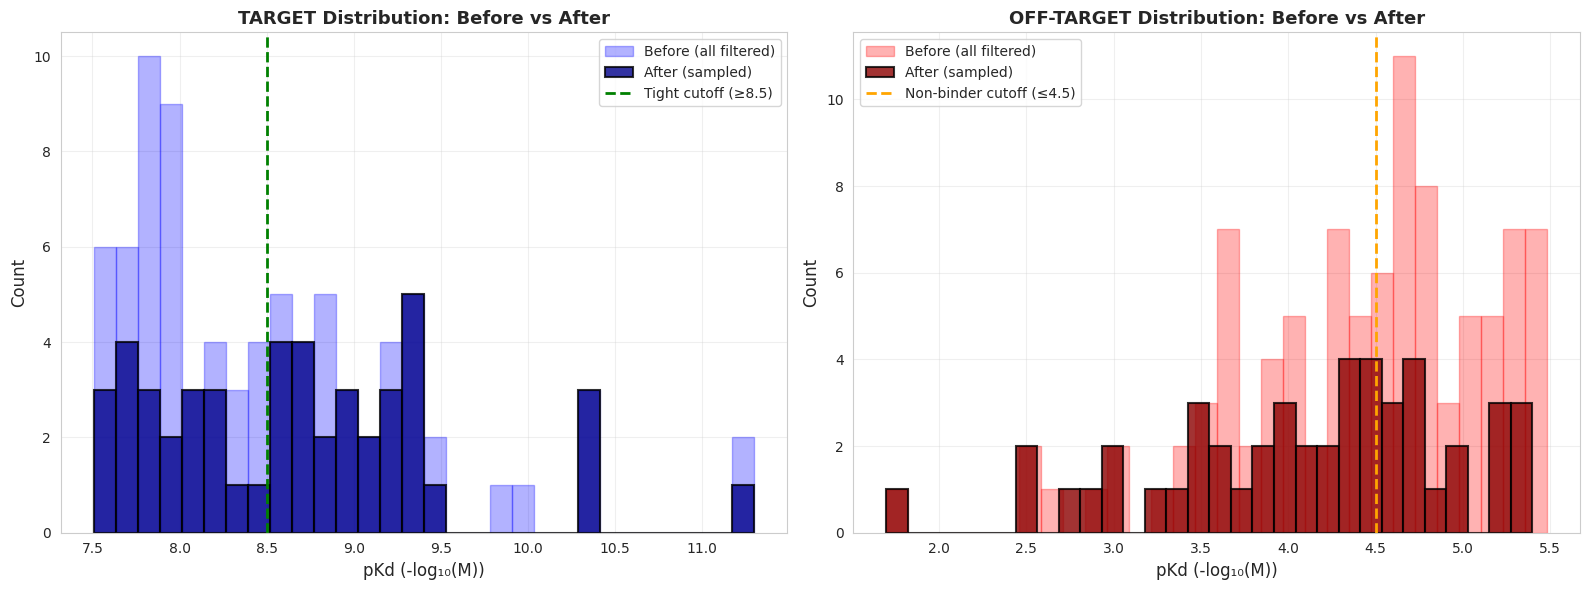

✅ Saved affinity comparison plot to /scratch/yunmin/data/db/graph/bdb/clustered/plots/bindingdb_Kd_clustering_affinity_before_after.png

AFFINITY STATISTICS COMPARISON

TARGETS:
  Before: Mean=8.54, Median=8.35, Std=0.83
  After:  Mean=8.68, Median=8.66, Std=0.83
  Range:  Before [7.5, 11.3] → After [7.5, 11.3]

OFF-TARGETS:
  Before: Mean=4.39, Median=4.54, Std=0.76
  After:  Mean=4.11, Median=4.27, Std=0.84
  Range:  Before [1.7, 5.5] → After [1.7, 5.4]


In [19]:
print("="*60)
print("AFFINITY DISTRIBUTION: BEFORE vs AFTER SAMPLING")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Target histogram
axes[0].hist(df_filtered[df_filtered['target_type'] == 'target'][f'p{ASSAY_TYPE}'], 
             bins=30, alpha=0.3, label='Before (all filtered)', color='blue', edgecolor='blue')
axes[0].hist(final_selection[final_selection['target_type'] == 'target'][f'p{ASSAY_TYPE}'], 
             bins=30, alpha=0.8, label='After (sampled)', color='darkblue', edgecolor='black', linewidth=1.5)
axes[0].axvline(TIGHT_BINDER_CUTOFF, color='green', linestyle='--', linewidth=2, label=f'Tight cutoff (≥{TIGHT_BINDER_CUTOFF})')
axes[0].set_xlabel(f'p{ASSAY_TYPE} (-log₁₀(M))', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('TARGET Distribution: Before vs After', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Off-target histogram
axes[1].hist(df_filtered[df_filtered['target_type'] == 'off_target'][f'p{ASSAY_TYPE}'], 
             bins=30, alpha=0.3, label='Before (all filtered)', color='red', edgecolor='red')
axes[1].hist(final_selection[final_selection['target_type'] == 'off_target'][f'p{ASSAY_TYPE}'], 
             bins=30, alpha=0.8, label='After (sampled)', color='darkred', edgecolor='black', linewidth=1.5)
axes[1].axvline(NON_BINDER_CUTOFF, color='orange', linestyle='--', linewidth=2, label=f'Non-binder cutoff (≤{NON_BINDER_CUTOFF})')
axes[1].set_xlabel(f'p{ASSAY_TYPE} (-log₁₀(M))', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('OFF-TARGET Distribution: Before vs After', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / f'bindingdb_{ASSAY_TYPE}_clustering_affinity_before_after.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved affinity comparison plot to {OUT_DIR / 'plots' / f'bindingdb_{ASSAY_TYPE}_clustering_affinity_before_after.png'}")

# Print statistics comparison
print(f"\n{'='*60}")
print("AFFINITY STATISTICS COMPARISON")
print(f"{'='*60}")

for ttype, label in [('target', 'TARGETS'), ('off_target', 'OFF-TARGETS')]:
    before = df_filtered[df_filtered['target_type'] == ttype][f'p{ASSAY_TYPE}']
    after = final_selection[final_selection['target_type'] == ttype][f'p{ASSAY_TYPE}']
    
    print(f"\n{label}:")
    print(f"  Before: Mean={float(before.mean()):.2f}, Median={float(before.median()):.2f}, Std={float(before.std()):.2f}")
    print(f"  After:  Mean={float(after.mean()):.2f}, Median={float(after.median()):.2f}, Std={float(after.std()):.2f}")
    print(f"  Range:  Before [{float(before.min()):.1f}, {float(before.max()):.1f}] → After [{float(after.min()):.1f}, {float(after.max()):.1f}]")

### 8-6. Diversity Analysis

In [20]:
def shannon_entropy(counts):
    """Calculate Shannon entropy for diversity."""
    total = counts.sum()
    probs = counts / total
    return -np.sum(probs * np.log2(probs + 1e-10))

size_entropy = shannon_entropy(final_selection['size_category'].value_counts())
affinity_entropy = shannon_entropy(final_selection['affinity_tier'].value_counts())

print("Diversity scores (higher = more diverse):")
print(f"  - Size diversity: {size_entropy:.2f}")
print(f"  - Affinity diversity: {affinity_entropy:.2f}")

Diversity scores (higher = more diverse):
  - Size diversity: 1.49
  - Affinity diversity: 1.95


## 9. Save Outputs

In [21]:
# Save clustered dataset
output_path = OUT_DIR / f"bindingdb_{ASSAY_TYPE}_clustered_stage1.csv"
final_selection.to_csv(output_path, index=False)
print(f"✅ Saved clustered dataset: {output_path}")

# Save metadata
metadata = {
    "pipeline": "SAIR Fast Clustering (Stage 1)",
    "timestamp": datetime.now().isoformat(),
    "input": {
        "file": INPUT_CSV,
        "initial_rows": initial_rows,
        "initial_proteins": int(df['protein_key'].nunique())
    },
    "filtering": {
        "min_targets_per_protein": MIN_TARGETS_PER_PROTEIN,
        "min_offtargets_per_protein": MIN_OFFTARGETS_PER_PROTEIN,
        "proteins_after_filter": len(valid_proteins),
        "rows_after_filter": len(df_filtered)
    },
    "clustering_criteria": {
        "tight_binder_cutoff": TIGHT_BINDER_CUTOFF,
        "non_binder_cutoff": NON_BINDER_CUTOFF,
        "cluster_keys": cluster_keys,
        "total_clusters": int(n_clusters)
    },
    "sampling_strategy": {
        "method": "balanced_per_protein",
        "max_samples_per_protein": 3,  # Adjust based on your actual value
        "target_total_samples": TARGET_SAMPLES,
        "proteins_sampled": proteins_sampled if 'proteins_sampled' in locals() else int(final_selection['protein_key'].nunique())
    },
    "output": {
        "total_selected": len(final_selection),
        "targets_selected": int((final_selection['target_type'] == 'target').sum()),
        "offtargets_selected": int((final_selection['target_type'] == 'off_target').sum()),
        "unique_proteins": int(final_selection['protein_key'].nunique()),
        "affinity_distribution": {k: int(v) for k, v in final_selection['affinity_tier'].value_counts().to_dict().items()},
        "size_distribution": {k: int(v) for k, v in final_selection['size_category'].value_counts().to_dict().items()},
        "diversity_scores": {
            "size": float(size_entropy),
            "affinity": float(affinity_entropy)
        }
    }
}

metadata_path = OUT_DIR / f"bindingdb_{ASSAY_TYPE}_clustering_stage1_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Saved metadata: {metadata_path}")

print("\n" + "="*60)
print("STAGE 1 COMPLETE")
print("="*60)
print(f"Next: Run Stage 2 validation on {output_path}")

✅ Saved clustered dataset: /scratch/yunmin/data/db/graph/bdb/clustered/bindingdb_Kd_clustered_stage1.csv
✅ Saved metadata: /scratch/yunmin/data/db/graph/bdb/clustered/bindingdb_Kd_clustering_stage1_metadata.json

STAGE 1 COMPLETE
Next: Run Stage 2 validation on /scratch/yunmin/data/db/graph/bdb/clustered/bindingdb_Kd_clustered_stage1.csv
